# 03. 수익률과 방향 예측

두 가지를 따로 본다.

1. **수익률 회귀**: h거래일 뒤 가격 변화의 크기까지 맞히는 문제. 기준선은 Naive(가격 유지)다.
2. **방향 확률**: 오를 확률만 맞히는 문제. 확률이 충분히 높거나 낮을 때만 "지금 구매 / 미루기" 신호를 내고, 애매하면 판단을 보류한다. 기준선은 학습 구간의 상승 비율을 늘 말하는 것이다.

모든 선택(모델, 설정, 확률 수축 정도, 신호 임계값)은 **개발 구간(2012–2021) walk-forward**로 한다. 그 뒤 보류 구간(2022–2025)을 매년 다시 학습하며 한 번 평가한다.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score
from torch import nn

import common
from coffee.config import DEV_YEARS, HOLDOUT_YEARS, HORIZONS
from coffee.evaluate import LOOKBACK, block_bootstrap_rmse_diff, direction_metrics, fold_rows, metrics
from coffee.features import ALL_FEATURES, build_dataset
from coffee.models import (DLinearModel, LightGBMClassifier, LightGBMModel, LogisticModel, Momentum, Naive,
                           RidgeModel, ScaledReturn)
from coffee.sources import load_sources

torch.set_num_threads(4)
data = build_dataset(load_sources())
SETS = {int(h): value for h, value in common.load_result("feature_sets").items()}


def walk_forward(h, make, years):
    # 연도마다 그 전까지의 자료로 학습해 그해를 예측하고, 예측과 학습 구간 상승 비율을 이어 붙인다.
    y = data[f"y_{h}"].to_numpy()
    out = {"y": [], "pred": [], "base": [], "rows": []}
    for year in years:
        fit, test = fold_rows(data, ALL_FEATURES, h, year, years[-1])
        out["pred"].append(make().fit(data, fit, y[fit]).predict(data, test))
        out["y"].append(y[test])
        out["base"].append(np.full(len(test), (y[fit] > 0).mean()))
        out["rows"].append(test)
    return {key: np.concatenate(value) for key, value in out.items()}

## 1. 수익률 회귀

In [2]:
class _LSTMNet(nn.Module):
    def __init__(self, n_features, hidden):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        return self.head(self.lstm(x)[0][:, -1]).squeeze(-1)


class LSTMModel:
    # 학부 원본의 Attention·정적 피처 분기·복합 손실은 빼고, 60일 창 → 1층 LSTM → 수익률로 단순화했다.
    name = "LSTM"

    def __init__(self, features, hidden=32, epochs=15, seeds=(0, 1)):
        self.features, self.hidden, self.epochs, self.seeds = list(features), hidden, epochs, seeds

    def _windows(self, data, rows):
        values = data[self.features].to_numpy(np.float32)
        windows = np.stack([values[row - LOOKBACK + 1: row + 1] for row in rows])
        return torch.tensor((windows - self.mean_) / self.std_)

    def fit(self, data, rows, y):
        values = data[self.features].to_numpy(np.float32)[rows]
        self.mean_, self.std_ = values.mean(axis=0), values.std(axis=0) + 1e-8  # 학습 행으로만 표준화
        self.y_mean_, self.y_std_ = float(y.mean()), float(y.std())
        x, target = self._windows(data, rows), torch.tensor(((y - self.y_mean_) / self.y_std_).astype(np.float32))
        self.nets_ = []
        for seed in self.seeds:
            torch.manual_seed(seed)
            net, generator = _LSTMNet(len(self.features), self.hidden), torch.Generator().manual_seed(seed)
            optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
            for _ in range(self.epochs):  # epoch는 고정. 평가 구간을 보고 멈추지 않는다.
                order = torch.randperm(len(x), generator=generator)
                for start in range(0, len(x), 64):
                    batch = order[start:start + 64]
                    optimizer.zero_grad()
                    nn.functional.mse_loss(net(x[batch]), target[batch]).backward()
                    optimizer.step()
            self.nets_.append(net.eval())
        return self

    def predict(self, data, rows):
        with torch.no_grad():
            output = np.mean([net(self._windows(data, rows)).numpy() for net in self.nets_], axis=0)
        return output * self.y_std_ + self.y_mean_

In [3]:
def regression_models(h):
    features = SETS[h]["regression"]
    models = {
        "Naive": lambda: Naive(),
        "Momentum": lambda: Momentum(h),
        "Ridge": lambda: ScaledReturn(RidgeModel(features, alpha=100), h),
        "LightGBM": lambda: ScaledReturn(LightGBMModel(features, n_estimators=150, num_leaves=7, min_child_samples=100), h),
        "DLinear": lambda: ScaledReturn(DLinearModel(features, alpha=1000), h),
    }
    if h == 20:  # LSTM은 학습이 오래 걸려 대표 지평(20일)에서만 비교한다
        models["LSTM"] = lambda: LSTMModel(features)
    return models


regression = []
for h in HORIZONS:
    results = {name: walk_forward(h, make, DEV_YEARS) for name, make in regression_models(h).items()}
    naive = results["Naive"]
    for name, result in results.items():
        m = metrics(result["y"], result["pred"])
        interval = block_bootstrap_rmse_diff(result["y"], result["pred"], naive["pred"], block=h)
        regression.append({"지평": h, "모델": name, "RMSE(Naive 대비 %)": 100 * (m["rmse"] / metrics(naive["y"], naive["pred"])["rmse"] - 1),
                           "RMSE 차이 95% 구간": f"[{interval['low']:+.4f}, {interval['high']:+.4f}]",
                           "균형정확도": m["balanced_acc"]})
regression = pd.DataFrame(regression)
regression.set_index(["지평", "모델"]).round(3)

RMSE(Naive 대비 %)      RMSE 차이 95% 구간  균형정확도
지평 모델                                                   
5  Naive                0.000  [+0.0000, +0.0000]    NaN
   Momentum            43.485  [+0.0175, +0.0239]  0.477
   Ridge                1.201  [-0.0002, +0.0013]  0.491
   LightGBM             0.939  [-0.0002, +0.0011]  0.510
   DLinear              7.492  [+0.0021, +0.0051]  0.490
20 Naive                0.000  [+0.0000, +0.0000]    NaN
   Momentum            49.211  [+0.0338, +0.0568]  0.448
   Ridge                4.371  [+0.0002, +0.0079]  0.528
   LightGBM             3.815  [+0.0001, +0.0069]  0.503
   DLinear             14.133  [+0.0053, +0.0211]  0.538
   LSTM                17.072  [+0.0073, +0.0244]  0.570
60 Naive                0.000  [+0.0000, +0.0000]    NaN
   Momentum            46.118  [+0.0261, +0.0976]  0.527
   Ridge                4.929  [+0.0014, +0.0120]  0.440
   LightGBM            14.269  [+0.0080, +0.0316]  0.452
   DLinear             19.866  [+0.0021, +0.0549]  0.499

**수익률의 크기는 Naive를 이기지 못했다.** 모든 모델의 RMSE가 Naive보다 크고, 5일 Ridge·LightGBM을 빼면 블록 bootstrap 구간도 0보다 위에 있다. 학부 모델을 단순화한 LSTM(Attention·정적 피처 분기·복합 손실 제외)도 20일에서 Naive보다 17% 나빴다. 커피 선물 가격은 공개 정보를 빠르게 반영해, 이 자료로는 '얼마나 오를지'를 맞히기 어렵다. 서비스의 중심 전망은 현재가(Naive)로 두고, 대신 변동 폭(04)과 방향 확률을 함께 보여 준다.

## 2. 방향 확률

In [4]:
def direction_models(h):
    features = SETS[h]["direction"]
    return {
        "Logistic": lambda: LogisticModel(features, C=0.05),
        "LightGBM분류(약한 정규화)": lambda: LightGBMClassifier(features, n_estimators=200, min_child_samples=80),
        "LightGBM분류(강한 정규화)": lambda: LightGBMClassifier(features, n_estimators=100, min_child_samples=200),
    }


def shrink(result, weight):
    # 과신된 확률을 학습 구간 상승 비율 쪽으로 당긴다. weight=1이면 그대로, 0이면 늘 기본 비율.
    return result["base"] + weight * (result["pred"] - result["base"])


direction_dev, best_direction = {}, {}
rows = []
for h in HORIZONS:
    for name, make in direction_models(h).items():
        result = walk_forward(h, make, DEV_YEARS)
        moved = result["y"] != 0
        up = (result["y"][moved] > 0).astype(float)
        briers = {w: np.mean((shrink(result, w)[moved] - up) ** 2) for w in np.linspace(0, 1, 21)}
        weight = min(briers, key=briers.get)
        direction_dev[h, name] = (result, weight)
        rows.append({"지평": h, "모델": name, "AUC": roc_auc_score(up, result["pred"][moved]),
                     "Brier(원래)": briers[1.0], "Brier(수축)": briers[weight], "Brier(기본 비율)": briers[0.0],
                     "수축 계수": weight})
direction_table = pd.DataFrame(rows)
direction_table.set_index(["지평", "모델"]).round(4)

AUC  Brier(원래)  Brier(수축)  Brier(기본 비율)  수축 계수
지평 모델                                                                   
5  Logistic            0.4791     0.2696     0.2508        0.2508   0.00
   LightGBM분류(약한 정규화)  0.5366     0.2582     0.2498        0.2508   0.25
   LightGBM분류(강한 정규화)  0.5121     0.2556     0.2507        0.2508   0.15
20 Logistic            0.5400     0.2845     0.2499        0.2517   0.20
   LightGBM분류(약한 정규화)  0.5831     0.2643     0.2453        0.2517   0.35
   LightGBM분류(강한 정규화)  0.5614     0.2563     0.2476        0.2517   0.40
60 Logistic            0.5265     0.3070     0.2622        0.2633   0.15
   LightGBM분류(약한 정규화)  0.5810     0.2771     0.2562        0.2633   0.35
   LightGBM분류(강한 정규화)  0.5410     0.2721     0.2596        0.2633   0.35

LightGBM 분류기(약한 정규화)의 AUC가 세 지평 모두 가장 높다(0.54~0.58). 하지만 원래 확률로는 Brier가 기본 비율보다 나쁘다. 순위는 맞히지만 확률이 너무 극단적이라는 뜻이다. 확률을 기본 비율 쪽으로 65~75% 줄이면(수축 계수 0.25~0.35) Brier가 기본 비율보다 조금 나아진다. 확신이 약한 모델이라는 것을 숫자로 인정하는 셈이다.

In [5]:
# 지평마다 AUC가 가장 높은 모델을 고르고, 신호 임계값은 개발 구간에서 신호 빈도 20% 이상 중 적중률이 가장 높은 값으로 정한다.
selection = {}
threshold_rows = []
for h in HORIZONS:
    table = direction_table[direction_table["지평"] == h].set_index("모델")
    name = table["AUC"].idxmax()
    result, weight = direction_dev[h, name]
    prob = shrink(result, weight)
    candidates = {}
    for threshold in (0.52, 0.55, 0.58, 0.60, 0.65):
        d = direction_metrics(result["y"], prob, base_rate=result["base"].mean(), threshold=threshold)
        threshold_rows.append({"지평": h, "임계값": threshold, "신호 빈도": d["coverage"], "신호 적중률": d["precision"]})
        if d["coverage"] >= 0.2:
            candidates[threshold] = d["precision"]
    threshold = max(candidates, key=candidates.get) if candidates else None
    selection[h] = {"model": name, "shrink": float(weight), "threshold": threshold, "features": SETS[h]["direction"]}
    print(f"{h}거래일: {name}, 수축 {weight:.2f}, 임계값 {threshold}")
pd.DataFrame(threshold_rows).pivot(index="임계값", columns="지평", values=["신호 빈도", "신호 적중률"]).round(3)

5거래일: LightGBM분류(약한 정규화), 수축 0.25, 임계값 0.52
20거래일: LightGBM분류(약한 정규화), 수축 0.35, 임계값 0.58
60거래일: LightGBM분류(약한 정규화), 수축 0.35, 임계값 0.6


신호 빈도               신호 적중률              
지평       5      20     60     5      20     60
임계값                                           
0.52  0.582  0.869  0.889  0.532  0.580  0.522
0.55  0.148  0.657  0.727  0.496  0.591  0.540
0.58  0.017  0.435  0.566  0.452  0.603  0.540
0.60  0.002  0.305  0.448  0.667  0.580  0.549
0.65  0.000  0.059  0.159    NaN  0.606  0.517

수축한 확률은 0.5 근처에 몰려, 5일은 임계값을 0.55로만 올려도 신호 빈도가 15%로 줄어든다. 신호 빈도 20% 이상이라는 조건 아래에서 임계값은 5 / 20 / 60일 0.52 / 0.58 / 0.60으로 정해졌고, 개발 구간의 신호 적중률은 53% / 60% / 55%다.

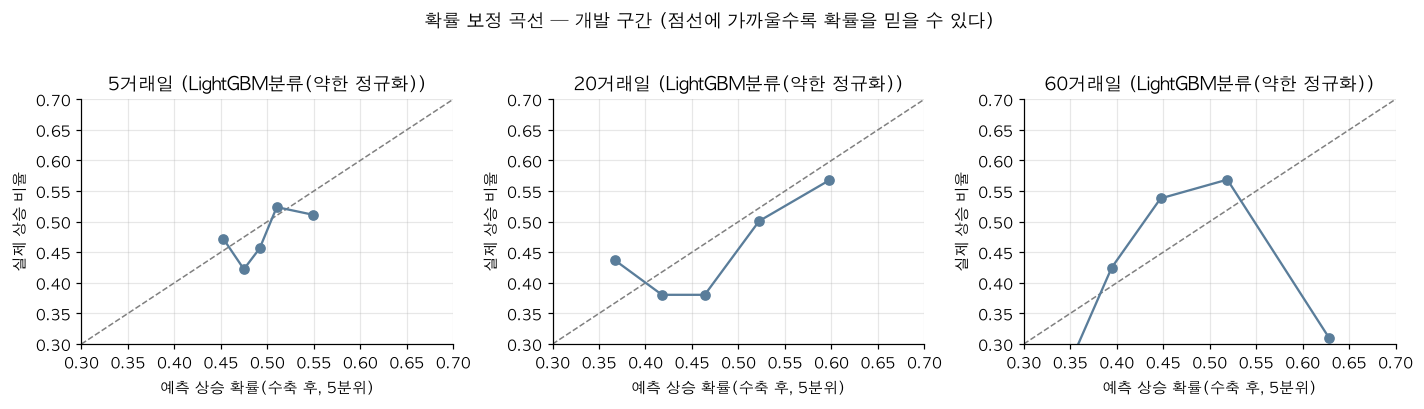

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, h in zip(axes, HORIZONS):
    result, weight = direction_dev[h, selection[h]["model"]]
    moved = result["y"] != 0
    prob, up = shrink(result, weight)[moved], (result["y"][moved] > 0)
    bins = pd.qcut(prob, 5, duplicates="drop")
    calibration = pd.DataFrame({"예측 확률": prob, "실제 상승": up}).groupby(bins, observed=True).mean()
    ax.plot([0.3, 0.7], [0.3, 0.7], color="gray", ls="--", lw=1)
    ax.plot(calibration["예측 확률"], calibration["실제 상승"], marker="o", color="#5a7d9a")
    ax.set(title=f"{h}거래일 ({selection[h]['model']})", xlabel="예측 상승 확률(수축 후, 5분위)", ylabel="실제 상승 비율",
           xlim=(0.3, 0.7), ylim=(0.3, 0.7))
fig.suptitle("확률 보정 곡선 — 개발 구간 (점선에 가까울수록 확률을 믿을 수 있다)", y=1.02)
fig.tight_layout()
common.save_fig(fig, "direction_calibration.png")
plt.show()

## 3. 보류 구간(2022–2025)

개발 구간에서 정한 모델·수축 계수·임계값을 그대로 쓰고, 2022–2025년을 매년 다시 학습하며 평가한다.

In [7]:
holdout_rows, holdout_direction = [], {}
for h in HORIZONS:
    naive = walk_forward(h, Naive, HOLDOUT_YEARS)
    for name in ("Ridge", "LightGBM"):
        result = walk_forward(h, regression_models(h)[name], HOLDOUT_YEARS)
        holdout_rows.append({"지평": h, "과제": "수익률", "모델": name,
                             "지표": "RMSE Naive 대비 %",
                             "값": 100 * (metrics(result["y"], result["pred"])["rmse"] / metrics(naive["y"], naive["pred"])["rmse"] - 1)})
    choice = selection[h]
    result = walk_forward(h, direction_models(h)[choice["model"]], HOLDOUT_YEARS)
    result["pred"] = shrink(result, choice["shrink"])
    holdout_direction[h] = result
    d = direction_metrics(result["y"], result["pred"], base_rate=result["base"].mean(), threshold=choice["threshold"])
    for key, label in (("auc", "AUC"), ("brier", "Brier"), ("base_brier", "Brier(기본 비율)"),
                       ("coverage", "신호 빈도"), ("precision", "신호 적중률"), ("up_rate", "실제 상승 비율")):
        holdout_rows.append({"지평": h, "과제": "방향", "모델": choice["model"], "지표": label, "값": d[key]})
holdout = pd.DataFrame(holdout_rows)
holdout.pivot_table(index=["과제", "지표"], columns="지평", values="값", sort=False).round(3)

지평                      5      20     60
과제  지표                                  
수익률 RMSE Naive 대비 %  0.133  0.858  3.807
방향  AUC              0.538  0.597  0.601
    Brier            0.249  0.244  0.251
    Brier(기본 비율)     0.250  0.251  0.254
    신호 빈도            0.620  0.350  0.357
    신호 적중률           0.549  0.615  0.526
    실제 상승 비율         0.498  0.504  0.577

보류 구간에서도 수익률 회귀는 Naive보다 나빴다. 방향 AUC는 0.54 / 0.60 / 0.60으로 개발 구간과 비슷하고, Brier도 세 지평 모두 기본 비율보다 조금 낫다. 신호 적중률은 55% / 62% / 53%다. 20일은 이 기간 실제 상승 비율(50%)보다 분명히 높지만, 60일은 상승 비율이 58%여서 늘 '지금 구매'라고 말한 것보다 오히려 낮다.

## 4. 원두 구매 결정으로 보기

카페가 20거래일(약 한 달)마다 원두를 한 번 산다고 하자. 매번 "지금 살지, 20거래일 뒤에 살지"를 정한다.

- 정기 구매: 항상 지금
- 모델 신호: '미루기' 신호(상승 확률이 1−임계값 이하)면 20거래일 뒤에, 그 밖에는 지금 산다
- 무작위: 두 선택의 평균, 오라클: 둘 중 싼 쪽(미래를 안다고 할 때)

결정 시점은 겹치지 않게 20거래일 간격으로 잡는다.

In [8]:
def purchase(result, threshold, h=20):
    decisions = np.arange(0, len(result["rows"]), h)
    rows = result["rows"][decisions]
    now = data["close"].to_numpy()[rows]
    later = now * np.exp(result["y"][decisions])
    wait = result["pred"][decisions] <= 1 - threshold
    costs = {"정기 구매(항상 지금)": now, "모델 신호": np.where(wait, later, now),
             "무작위": (now + later) / 2, "오라클": np.minimum(now, later)}
    return pd.Series({name: 100 * (cost / now - 1).mean() for name, cost in costs.items()}), len(rows), int(wait.sum())


dev_result, weight = direction_dev[20, selection[20]["model"]]
dev_result = {**dev_result, "pred": shrink(dev_result, weight)}
table = {}
for label, result in (("개발 구간", dev_result), ("보류 구간", holdout_direction[20])):
    table[label], n, waits = purchase(result, selection[20]["threshold"])
    print(f"{label}: 결정 {n}번 중 미루기 {waits}번")
costs = pd.DataFrame(table)
print("정기 구매 대비 평균 구매 가격 차이(%) — 음수일수록 싸게 샀다")
costs.round(2)

개발 구간: 결정 121번 중 미루기 37번
보류 구간: 결정 45번 중 미루기 14번
정기 구매 대비 평균 구매 가격 차이(%) — 음수일수록 싸게 샀다


,개발 구간,보류 구간
정기 구매(항상 지금),0.00,0.00
모델 신호,0.05,0.10
무작위,0.24,0.83
오라클,-3.29,-3.28


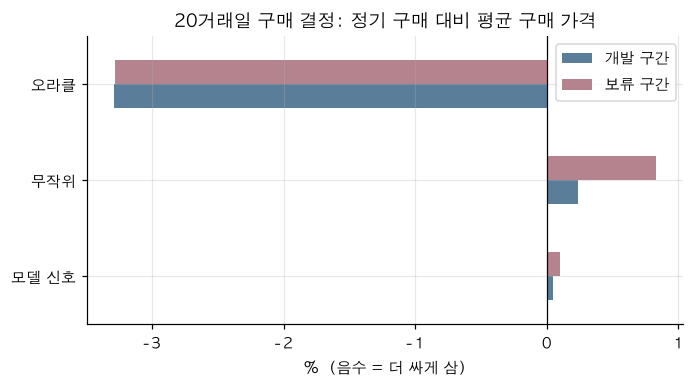

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.4))
costs.drop(index="정기 구매(항상 지금)").plot.barh(ax=ax, color=["#5a7d9a", "#b5838d"])
ax.axvline(0, color="black", lw=0.8)
ax.set(title="20거래일 구매 결정: 정기 구매 대비 평균 구매 가격", xlabel="%  (음수 = 더 싸게 삼)")
common.save_fig(fig, "buy_timing.png")
plt.show()

방향 신호로 구매 시점을 고르면 정기 구매와 거의 같은 값에 샀다(개발 +0.05%, 보류 +0.10%). 무작위로 미룬 것(+0.24%, +0.83%)보다는 덜 비쌌지만 정기 구매보다 싸게 사지는 못했다. 방향을 조금 맞히더라도, 가격이 크게 오른 시기에 '미루기'를 한 번 틀리면 그 비용이 맞혔을 때의 이득보다 크다. **방향 정확도가 곧 의사결정 가치는 아니다.** 그래서 서비스에서는 방향 확률을 참고 정보로만 보여 주고, 구매 판단의 근거로는 변동 폭(04)을 함께 제시한다.

In [10]:
common.save_result("direction_selection", {str(h): value for h, value in selection.items()})
common.save_result("return_direction_results", {
    "regression_dev": regression.round(5).to_dict("records"),
    "direction_dev": direction_table.round(5).to_dict("records"),
    "holdout": holdout.round(5).to_dict("records"),
    "purchase": costs.round(3).to_dict(),
})

## 정리

- 수익률 크기: 어떤 모델도 Naive를 넘지 못했다(LSTM 포함). 중심 전망은 현재가로 둔다.
- 방향 확률: LightGBM 분류기가 AUC 0.54~0.60(개발·보류)으로 무작위보다 낫고, 수축한 확률의 Brier가 기본 비율보다 조금 낫다. 약하지만 실제 신호다. 다만 60일 신호는 보류 구간에서 늘 '구매'보다 낫지 않았다.
- 구매 결정: 방향 신호만으로 구매 시점을 고르면 정기 구매보다 낫지 않았다. 방향 확률은 참고 정보로 보여 준다.